# Homophily in networks
Cassidy Waldrip

#### Goal of today's class:

1. Define homophily in networks
2. Understand relevance and effects of homophily
3. Learn tools for measuring homophily and practice using them
4. Look at real world examples of homophilous networks

## Section 1: Defining homophily in networks


### 1.1: Basic definition

*People “love those who are like themselves” - Aristotle*

*“Similarity begets friendship” - Plato*

Homophily in networks is the idea that nodes are more likely to be associated with other nodes that share similar traits.
Homophily, particularly in social networks, has been noted and studied for a very long time. It makes intuitive sense to us as humans - we see people around us more likely to be in groups that have similar locations, races, interests, genders, and many other traits.



![](https://drive.google.com/uc?export=view&id=1U9UT2nsHdOMY3dzWVzCRfyiHYgxx3vdO)

In this figure, from [13], we see interactions between fishers in Hawaii. The colors represent different ethnicities - we can see a clear preference for associating within your own ethnicity.



### 1.2: What came first, the chicken or the egg?

I am being careful with my wording of the definition of homophily - let's read it again:

Homophily in networks is the idea that nodes are more likely **to be associated** with other nodes that share similar traits.

It is tempting to say that nodes are more likely *to associate* with nodes that share similar traits, meaning that the similarities are *causing* connections between nodes. Would that really be true in all cases?

Consider the example of the fishers from above - can we say with a surety that those in the network are 'choosing' to associate with those of their same ethnicity? Could there be other factors at play?

Consider an example from this paper [14] that discusses references between political blogs.

![](https://drive.google.com/uc?export=view&id=1_0zN0ldJRCmxTSHmq06Lpj9-5YlEa8uq)

We can clearly see that left-leaning bloggers tend to reference the blogs of other left-leaning bloggers, and right-leaning bloggers tend to reference the blogs of other right-leaning bloggers.

But is political leaning always the factor *causing* association?

Try to come up with a few other explanations for the homophily we can observe in this graph.

The idea of homophily creates something of a chicken-and-egg question - are nodes associating because they are similar, or do nodes become more similar because they are connected? Are the fishers in the first example choosing to associate because of race, or are there structural factors that encourage homophily? Are the bloggers linking because of political affiliation, or is their political stance being influenced by their connections?

There are several attempts to answer this question, and the simplified consensus is that it's complicated. [1][2][4][15] Your main takeaway from this though exercise should be that similar traits between nodes do not necessarily *cause* connection.

### 1.3: Defining similar traits

What do we mean when we say that nodes with "similar traits" are associated in homophilous networks?

A baseline is node degree. In many real-world networks, nodes of high degree tend to be associated with other nodes of high degree. [1][17] This phenomenon does not occur in all networks, but is a good place to start. Preferential attachment models are based on this idea, and generate graphs where nodes of similar degree are more likely to connect to one another.

As hinted above, there are other ways that nodes can be similar. These are mainly encoded as attributes when we work with networks. In social networks, these attributes could be location, age, gender, employment, or any number of other traits.

One of the challenges of thinking about homophily is deciding whice traits to focus on. As in the example with the fishers above, it is easy to look at ethnicity, but there are other hidden traits that we may have failed to take into account, such as where groups of people are located.

In this chapter, we will start by measuring homophily by looking at degree correlation, and then we will expand into looking at attributes on nodes.




### 1.4: Subcategories of homophily

There are a few canonized categories of homophily that attempt to differentiate between different patterns and causes of the phenomenon. As we look at different instances of homophilous networks, try to think about what categories of homophily the networks could fit into.



#### Status vs. value homophily

In their 1954 paper [2], Lazarsfeld and Merton defined two distinct kinds of homophily in social networks: status homophily and value homophily. Status homophily can be though of as more "stable" traits in society - for example race, ethnicity, and age. It also includes acquired characteristics such as education level, occupation, and religion. Basically, status homophily encompasses most tangible social statuses that a person can have.

Value homophily, on the other hand, is more hand-wavey. It includes homophily based on values (shocker), beliefs, and personal attitudes. I think of value homophily as more fluid - one's opinions and values are subject to change more easily than one's occupation or age.

The paper ends up claiming that value homophily often is derived from status homophily, as social positions tend to influence a person's attitudes toward the world around them.


#### Choice vs. induced homophily

Another distinction of types of homophily comes from McPherson and Smith-Lovin in a 1987 paper [3]: choice version induced homophily. This one is fairly self-explanitory. In social networks, choice homophily is defined as homophily that arises due to people's propensity to selectively associate with those who are like them. Induced homophily, on the other hand, describes situations where structural circumstances and limitations lead to homophily by limiting the choices of whom to associate with.

### 1.5: Presence and effect of homophily


#### Where does homophily show up?

* Social networks - mainly here. The vast majority of the literature referenced in this chapter discusses homophily, particularly homophily based on node attributes, in the lens of social networks. Some examples include:
  * Celebrities generally choosing to date other celebrities [22]
  * Adolescents forming friendships based on similarities with regards to marijuana use [15]
  * Marketing: homophily between marketers and their customers tends to increase brand value [11]
  * Epidemiology: rates of disease spread are positively correlated with levels of homophily in groups of people [10]
* Other networks:
  * Protein similarity: a small number of protein families are highly connected and dominate the network [18]
  * Dolphin companionship: dolphins are part of communities correlated to age and gender [19]

  ![](https://drive.google.com/uc?export=view&id=1ry87Qvs9l7jwokxKaekXUYWR3pNlASXG)

  Dolphin communities from [19]. Colors represent different communities. Males are squares and females are circles, while dolphins of unknown sex are triangles.



#### What are the effects of homophily?
* Reinforcement of social norms
* Increased tolerance among groups, less tolerance for those outside of groups [20]
* "Echo chambers" and polarization
* Limits on innovation
* Limited inclusion of minorities [21]

## Section 2: Measuring homophily

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import random

### 2.1: Degree correlation

We'll start with the simplest notion of homophily - degree assortativity.

Let's work together to generate 3 graphs, all with the same number of nodes.

A random graph is provided below.

In [ ]:
num_nodes = 50 # choose the number of nodes for all graphs

# Generate an initial random graph
degree_sequence = np.random.poisson(5, num_nodes)  # generate degree distribution
if sum(degree_sequence) % 2 != 0:
    degree_sequence[-1] += 1 # ensure even degree sequence
G_random = nx.configuration_model(degree_sequence) # generate a graph from degree sequence
G_random.remove_edges_from(nx.selfloop_edges(G_random))  # remove self-loops

Starting from the G_random graph, we want to rewire it in two different ways:
- Rewire it so that nodes are more likely to be connected to nodes of similar degree
- Rewire it so that nodes are less likely to be connected to nodes of similar degree

Let's make copies of the random graph:

In [ ]:
# Make copies of the random graph to manipulate
G_assortative = G_random.copy()
G_disassortative = G_random.copy()


Now it's up to you to fill in the `rewire` function below.  

In [ ]:
# Your turn!

def rewire_your_turn(G, num_attempts, assortative=True):
  """
  Inputs
  ------
  G : nx graph
      initial nx graph
  num_attempts : int
                 number of rewiring attempts
  assortative : bool
                If True, rewire so that nodes are more likely to be connected to nodes of similar degree.
                If False, rewire so that nodes are less likely to be connected to nodes of similar degree.

  Outputs
  -------
  G: nx graph
     graph with rewired edges
  """
  for _ in range(num_attempts): # try num_attempts rewirings
      edges = list(G.edges()) # get the edges in the graph
      u1, v1 = edges[np.random.randint(len(edges))] # get random edge
      u2, v2 = edges[np.random.randint(len(edges))] # get random edge

      if len(set([u1, v1, u2, v2])) == 4:  # ensure no duplicate or invalid edges
          ### YOUR CODE HERE ###
          pass

In [ ]:
# Answer to "Your turn" section

def rewire(G, num_attempts, assortative=True):
  """
  Inputs
  ------
  G : nx graph
      initial nx graph
  num_attempts : int
                 number of rewiring attempts
  assortative : bool
                If True, rewire so that nodes are more likely to be connected to nodes of similar degree.
                If False, rewire so that nodes are less likely to be connected to nodes of similar degree.

  Outputs
  -------
  G: nx graph
     graph with rewired edges
  """
  for _ in range(num_attempts):
      edges = list(G.edges())
      u1, v1 = edges[np.random.randint(len(edges))]
      u2, v2 = edges[np.random.randint(len(edges))]

      if len(set([u1, v1, u2, v2])) == 4:  # ensure no duplicate or invalid edges

          # Calculate degree differences for current and proposed connections
          current_diff = abs(G.degree[u1] - G.degree[v1]) + abs(G.degree[u2] - G.degree[v2])
          proposed_diff = abs(G.degree[u1] - G.degree[u2]) + abs(G.degree[v1] - G.degree[v2])

          # Rewire based on assortativity goals
          if assortative and proposed_diff < current_diff:
              G.remove_edge(u1, v1)
              G.remove_edge(u2, v2)
              G.add_edge(u1, u2)
              G.add_edge(v1, v2)
          elif not assortative and proposed_diff > current_diff:
              G.remove_edge(u1, v1)
              G.remove_edge(u2, v2)
              G.add_edge(u1, u2)
              G.add_edge(v1, v2)


Now let's try out our rewire function!

In [ ]:
# Rewire the random graph to increase assortativity
# rewire_your_turn(G_assortative, 2000, assortative=True)
# rewire_your_turn(G_disassortative, 2000, assortative=False)

rewire(G_assortative, 2000, assortative=True)
rewire(G_disassortative, 2000, assortative=False)


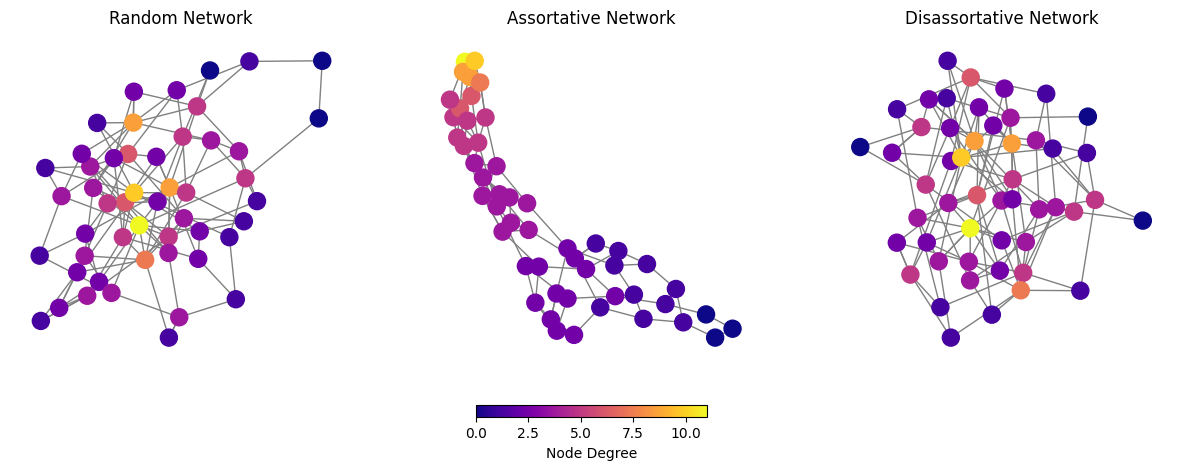

In [ ]:
# Plot the graphs!

# Create a spring layout for each graph
pos1 = nx.spring_layout(G_random, seed=42)
pos2 = nx.spring_layout(G_assortative, seed=42)
pos3 = nx.spring_layout(G_disassortative, seed=42)

# Normalize the degree for colormap scaling
def get_node_colors(graph):
    degrees = dict(graph.degree())
    norm = mcolors.Normalize(vmin=min(degrees.values()), vmax=max(degrees.values()))
    cmap = cm.plasma  # Choose a colormap
    return [cmap(norm(degrees[node])) for node in graph.nodes()]

# Get colors for each graph
colors1 = get_node_colors(G_random)
colors2 = get_node_colors(G_assortative)
colors3 = get_node_colors(G_disassortative)

# Plot the graphs side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Draw G_random
nx.draw(G_random, pos=pos1, ax=axes[0], node_color=colors1, edge_color="gray", node_size=150, font_size=10)
axes[0].set_title("Random Network")

# Draw G_assortative
nx.draw(G_assortative, pos=pos2, ax=axes[1], node_color=colors2, edge_color="gray", node_size=150, font_size=10)
axes[1].set_title("Assortative Network")

# Draw G_disassortative
nx.draw(G_disassortative, pos=pos3, ax=axes[2], node_color=colors3, edge_color="gray", node_size=150, font_size=10)
axes[2].set_title("Disassortative Network")

# Add colorbar for the degree scale
sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=mcolors.Normalize(vmin=0, vmax=max(max(dict(G_random.degree()).values()),
                                                                                  max(dict(G_assortative.degree()).values()),
                                                                                  max(dict(G_disassortative.degree()).values()))))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.1)
cbar.set_label("Node Degree")

plt.show()


What do you notice about each graph? Specifically pay attention to the heat map of node degrees.

Now, let's look at the degree correlation coefficient for each network. The degree correlation coefficient is based on the expected degrees of the nodes versus their actual degrees. It is a value between -1 and 1. If it is -1, that means that nodes only connect with nodes of different degree. If it is 1, nodes in the network only connect with nodes of the same degree. As you can imagine, if we have a value of 0, that indicates no correlation between degree and connections.

NetworkX has this coefficient as a built in function, so let's use it to compare degree correlation in the three networks we generated.

In [ ]:
# Compare degree correlation coefficients! What do you notice about each graph?
random_correlation = nx.degree_assortativity_coefficient(G_random)
assortative_correlation = nx.degree_assortativity_coefficient(G_assortative)
disassortative_correlation = nx.degree_assortativity_coefficient(G_disassortative)

print(f"Random Graph Degree Correlation: {random_correlation}")
print(f"Assortative Graph Degree Correlation: {assortative_correlation}")
print(f"Disassortative Graph Degree Correlation: {disassortative_correlation}")

Random Graph Degree Correlation: -0.15060899121919868
Assortative Graph Degree Correlation: 0.9004437610434453
Disassortative Graph Degree Correlation: -0.47865495892849963


### 2.1: Attributes and beyond

Now let's make this a little more robust. From previous examples, we know there is more to homophily than just degree. Let's consider one of our favorite networks - the Karate Club graph.

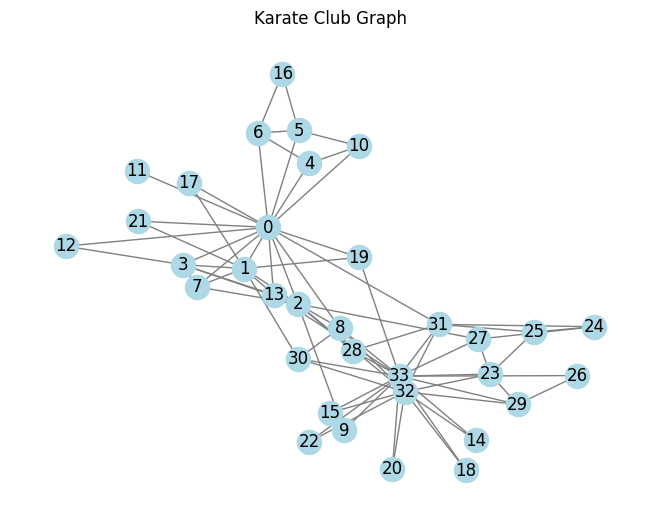

In [ ]:
# Draw the Karate Club graph
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray")
plt.title("Karate Club Graph")
plt.show()

Before we look at some other measures of homophily, let's try to measure homophily in the Karate Club graph using degree assortativity.

In [ ]:
# Get degree correlation of the Karate Club graph
karate_club_correlation = nx.degree_assortativity_coefficient(G)
print(f"Karate Club Graph Degree Correlation: {karate_club_correlation}")

Karate Club Graph Degree Correlation: -0.47561309768461413


Okay, so based on degree correlation alone, the graph is not at all assortative. In fact, it is disassortative. Does this mean that it does not contain homophily?

If we remember that the Karate Club network actually represents interactions between two different karate clubs' members, we might make the conjecture that there may be some homophily based on club membership, even though we can't see any by looking at degree correlation.

### 2.2: E-I Index

Let's implement an simple, older method for detecting homophily: the external-internal (E-I) index. It was first presented by David Krackhardt and Robert N. Stern in 1988 [5] as a simple way to measure the ratio of external to internal ties given a network with specific groups.

The algorithm for the E-I index is quite simple:

\begin{align}
\text{E-I Index} = \frac{EL - IL}{EL + IL}
\end{align}

where $EL$ is the total number of external links and $IL$ is the total number of internal links.

An external link is defined as an edge between nodes in different groups, whereas an internal link is an edge between nodes of the same group.

The E-I index will return a value between -1 and 1. The closer to -1 it is, the more homophily there is. Look at the equation and reason about why that is.

In [ ]:
# Your turn!

# Implement a function to measure the E-I index of nodes in a network that belong to certain groups. See docstring for hints.

def e_i_index_your_turn(G, attribute):
  '''
  Inputs
  ------

  G : NetworkX graph
  attribute: string
             the name of the attribute that you want to use to group nodes

  Outputs
  -------
  E-I index : float
              the E-I index of the network
  '''
  ### YOUR CODE HERE ###
  pass


In [ ]:
# Answer to "Your turn" section

def e_i_index(G, attribute):
  '''
  Inputs
  ------

  G : NetworkX graph
  attribute: string
             the name of the attribute that you want to use to group nodes

  Outputs
  -------
  E-I index : float
              the E-I index of the network
  '''
  external_links = 0
  internal_links = 0

  for e in G.edges():
    if G.nodes[e[0]][attribute] != G.nodes[e[1]][attribute]:
      external_links += 1
    else:
      internal_links += 1
  return (external_links - internal_links) / (external_links + internal_links)

Now we can measure homophily in the Karate Club graph using the E-I index.

In [ ]:
karate_club_e_i = e_i_index(G, 'club')
# karate_club_e_i = e_i_index_your_turn(G, 'club')
print(f"Karate Club Graph E-I Index: {karate_club_e_i}")

Karate Club Graph E-I Index: -0.717948717948718


What does the E-I index tell us about the graph?

### 2.2: Modern measures of homophily



#### Attribute assortativity

The most ubiquitous measure of homophily in networks used today is the quanitification of assortative mixing using the *attribute assortativity coefficient*. This coefficient was introduced by Newman in 2003 [16]. Assortative mixing is defined as "the correlations between properties of adjacent network nodes
known in the ecology and epidemiology literature" [16], and the accompanying coefficient is defined as follows:

\begin{align}
r = \frac{\text{trace}(\mathbf{M}) - \sum \mathbf{M}^2}{1 - \sum \mathbf{M}^2}
\end{align}

Where $\mathbf{M}$ is the attribute mixing matrix. The mixing matrix is defined as a $k × k$ matrix, where $k$ is the number of different categories an attribute has. $\mathbf{M}_{ij}$ is the proportion of edges in the network that connect nodes with attribute $i$ to nodes with attribute $j$.

The coefficient ranges between -1 and 1, with -1 being perfect disassortativity, 0 being no assortativity, and 1 being perfect assortativity.

Attribute assortativity "describes how intra- and inter-group connectivity diverges from what we expect solely due to degree connectivity of the nodes and groups." [7]

In [ ]:
def attribute_assortativity(M):
    """
    Adapted from NetworkX attribute_assortativity_coefficient source code.

    Compute assortativity for attribute mixing matrix M.

    Inputs
    ------
    M : numpy.ndarray
        2D array representing the attribute mixing matrix

    Outputs
    -------
    r : float
        The assortativity coefficient

    Notes
    -----
    This computes Eq. (2) in [16], (trace(e)-sum(e^2))/(1-sum(e^2)),
    where e is the joint probability distribution (mixing matrix)
    of the specified attribute.
    """
    if M.sum() != 1.0:
        M = M / M.sum()
    s = (M @ M).sum()
    t = M.trace()
    r = (t - s) / (1 - s)
    return float(r)

def attribute_assortativity_coefficient(G, attribute):
  """
  Adapted from NetworkX attribute_assortativity_coefficient source code.

  Compute attribute assortativity coefficient.

  Inputs
  ------
  G : NetworkX graph
  attribute: string
             the name of the attribute that you want to use to group nodes

  Outputs
  -------
  r : float
      The assortativity coefficient
  """
  M = nx.attribute_mixing_matrix(G, attribute)
  return attribute_assortativity(M)

Let's compute the attribute assortativity coefficient for the Karate Club graph from before.

In [ ]:
karate_club_assortativity = attribute_assortativity_coefficient(G, 'club')
print(f"Karate Club Attribute Assortativity: {karate_club_assortativity}")

Karate Club Attribute Assortativity: 0.717530864197531


#### Issues with assortativity

Now, can you think of an example of a network where these measures of homophily would not be accurate? In their recent publication, *On the inadequacy of nominal  assortativity for assessing  homophily in networks* [7], Karimi and Oliveira show some inherent problems with using attribute assortativity alone for some networks.

The main issue that they describe is that attribute assortativity has the inherent assumption that group sizes are relatively equal.

See the below figure from [7].

![](https://drive.google.com/uc?export=view&id=18-GIXYesppT9c8cJ-NPTTzjiYj0QH1i1)

Focusing on Figure 1a, we see that in the presence of a minority, attribute assortativity is less accurate than if the group sizes are relatively similar.

In order to address this issue, they present a modified version of attribute assortativity, called adjusted nominal assortativity. The adjusted version *normalizes* the mixing matrix, so that group size does not skew the results.

I provide the code from their paper for their adjustments below.

In [66]:
# taken from https://github.com/macoj/assortativity/blob/main/src/assortativity.py
# comments added by me to explain what is happening

def nx_group_fraction(nx_graph, attribute):
    """
    Inputs
    ------
    nx_graph : NetworkX graph
    attribute : string
                the name of the attribute that you want to use to group nodes

    Outputs
    -------
    counts : numpy array
             the number of nodes in each group
    unique : numpy array
             the unique values of the attribute for each group
    """
    nodes_group = [nx_graph.nodes[n][attribute] for n in nx_graph.nodes]
    unique, counts = np.unique(nodes_group, return_counts=True)
    counts, unique = list(zip(*sorted(zip(counts, unique))))
    counts = np.array(counts)
    return counts, unique

def nx_adjusted_assortativity(nx_graph, attribute):
    """
    Inputs
    ------
    nx_graph : NetworkX graph
    attribute : string
                the name of the attribute that you want to use to group nodes

    Outputs
    -------
    adjusted_assortativity : float
                             the adjusted assortativity coefficient
    """
    counts, unique = nx_group_fraction(nx_graph, attribute)
    group_map = dict([(unique[i], i) for i in range(len(unique))])

    absolute_mixing_matrix = nx.attribute_mixing_matrix(
        nx_graph, attribute, normalized=False, mapping=group_map)

    e_line = counts * counts.reshape(len(unique), 1) - np.diag(counts)

    # normalize the mixing matrix
    absolute_mixing_matrix = np.divide(absolute_mixing_matrix, e_line)
    absolute_mixing_matrix /= absolute_mixing_matrix.sum()

    # calculate assortativity
    sum_ai_bi = np.sum(absolute_mixing_matrix.sum(axis=0) * absolute_mixing_matrix.sum(axis=1))
    sum_eii = np.sum(absolute_mixing_matrix.diagonal())
    adjusted_assortativity = (sum_eii - sum_ai_bi) / (1 - sum_ai_bi)
    return adjusted_assortativity


We will test this adjustment in the following section by creating a network with different group sizes.

## Section 3: Activity - measuring homophily over time

Now that we have some tools to measure homophily, let's simulate an evolving network and apply those tools.

There is research to suggest that network evolution is affected by attributes on nodes [4][10]. As previously mentioned in this chapter, we cannot say that similarities between nodes necessarily induce connections in all cases, but there seems to be a correlation in certain social networks.

To simulate an evolving network, we will create a modified version of an Erdos-Renyi graph where instead of preferential attachment based on degree, we have preferential attachment based on node attributes. This technique is based loosely on Kibae Kim and Jorn Altmann's paper *Effect of homophily on network formation*, where they describe the importance of preferential attachment based on attributes besides degree.

The code below defines two functions: one to assign attributes to nodes in a graph give certain probabilities of each attribute, and one to add/remove edges from the graph based on attributes.

In [ ]:
def assign_attributes(G, attr_probs: dict):
  """
  Assign attributes to nodes in a graph.

  Inputs
  ------
  G : NetworkX graph
  attr_probs : dict
               dictionary of attributes and their probabilities

  Outputs
  -------
  G : NetworkX graph
      graph with attributes assigned to nodes
  """
  for node in G.nodes():
      attr = np.random.choice(list(attr_probs.keys()), p=list(attr_probs.values()))
      G.nodes[node]['attr'] = attr
  return G

def generate_homophily_er_graph(G, p_add_same, p_add_diff, p_remove_same, p_remove_diff):
    """
    Generate a graph with homophily based on node attributes.

    Inputs
    ------
    G : NetworkX graph
    n : int
        number of nodes in the graph
    p_add_same : float
                  probability of adding an edge between two nodes with the same attribute
    p_add_diff : float
                  probability of adding an edge between two nodes with different attributes
    p_remove_same : float
                    probability of removing an edge between two nodes with the same attribute
    p_remove_diff : float
                    probability of removing an edge between two nodes with different attributes

    Outputs
    -------
    G : NetworkX graph
        modified graph with homophily based on node attributes

    """
    for i in range(G.number_of_nodes()):
        for j in range(i + 1, G.number_of_nodes()):
            if G.nodes[i]['attr'] == G.nodes[j]['attr'] and G.has_edge(i,j):
                if random.random() < p_remove_same:
                    G.remove_edge(i, j)
            elif G.nodes[i]['attr'] == G.nodes[j]['attr']:
                if random.random() < p_add_same:
                    G.add_edge(i, j)
            elif G.nodes[i]['attr'] != G.nodes[j]['attr'] and G.has_edge(i,j):
                if random.random() < p_remove_diff:
                    G.remove_edge(i, j)
            else:
                if random.random() < p_add_diff:
                    G.add_edge(i, j)
    return G

Now we want to simulate the evolution of time in our generated network. We can do this by repeatedly calling the `generate_homophily_er_graph` to represent edges being added and removed with different probabilities.

Try to come up with probabilities for edge addition and removal that you would expect in a network of your choice. For example, if we were showing friendships in a high school between basketball players, the debate team, and choir, how would you expect different connections to form or dissolve?



In [ ]:
# Your turn!
nodes_list = [x for x in range(0, 100)]
G = nx.Graph()
G.add_nodes_from(nodes_list)

# Create a mapping of 3 attributes to their probabilities of appearing
### YOUR CODE HERE ###

# Assign attributes to the nodes in G based on their probabilities (use function from above)
### YOUR CODE HERE ###

# Choose probabilities for p_add_same, p_remove_same, p_add_diff, and p_remove_diff
### YOUR CODE HERE ###

# Run the generate_homophily_er_graph function 100 times, saving the state of the graph after each step
### YOUR CODE HERE ###

In [71]:
# Answer to "Your turn" section
nodes_list = [x for x in range(0, 100)]
G = nx.Graph()
G.add_nodes_from(nodes_list)

# Create a mapping of 3 attributes to their probabilities of appearing
attr_probs = {'A': 0.1, 'B': 0.0, 'C': 0.9}

# Assign attributes to the nodes in G based on their probabilities (use function from above)
G = assign_attributes(G, attr_probs)

# Choose probabilities for p_add_same, p_remove_same, p_add_diff, and p_remove_diff
p_add_same = 0.05
p_remove_same = 0.01
p_add_diff = 0.01
p_remove_diff = 0.1

# Run the generate_homophily_er_graph function 100 times, saving the state of the graph after each step
graphs_over_time = [G]
for i in range(100):
    G = generate_homophily_er_graph(G, p_add_same, p_add_diff, p_remove_same, p_remove_diff)
    graphs_over_time.append(G.copy())

Now, choose one or two of the measures of homophily that we implemented in the previous section and plot those measures of homophily over time.

Feel free to play with the initial attribute distributions, the probabilities of edge addition/removal, and the number of timesteps.

Present your plots to the class, and try to explain the results you see!

In [ ]:
# Your turn!

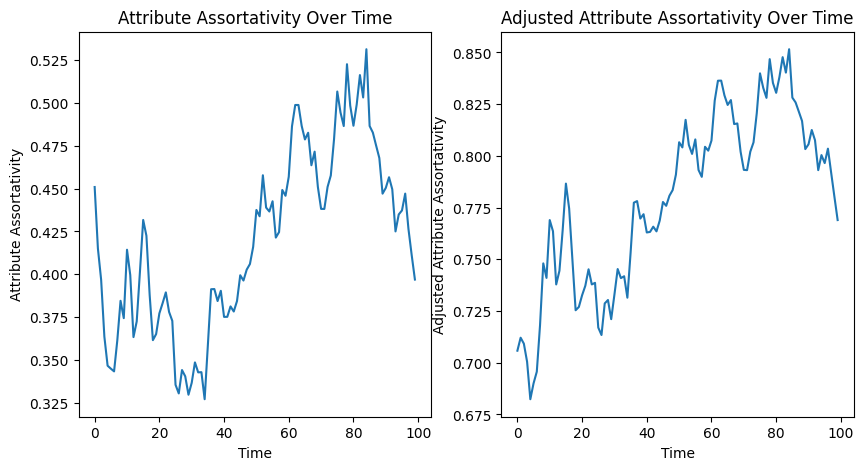

In [72]:
# Answer to "Your turn" section

# I chose to look at attribute assortativity and adjusted attribute assortativity

assortativity_over_time = []
for G in graphs_over_time[1:]:
  assortativity_over_time.append(attribute_assortativity_coefficient(G, 'attr'))

adjusted_assortativity_over_time = []
for G in graphs_over_time[1:]:
  adjusted_assortativity_over_time.append(nx_adjusted_assortativity(G, 'attr'))

# Plot the graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(assortativity_over_time)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Attribute Assortativity')
axes[0].set_title('Attribute Assortativity Over Time')

axes[1].plot(adjusted_assortativity_over_time)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Adjusted Attribute Assortativity')
axes[1].set_title('Adjusted Attribute Assortativity Over Time')

plt.show()

## Section 4: Case study - homophily in Facebook Page-Page network

Now we're going to explore homophily in a real network - Facebook Large Page-Page Network (https://snap.stanford.edu/data/facebook-large-page-page-network.html). This network contains Facebook pages and links between pages based on mutual likes between the pages.  

The network has ~22,000 nodes (Facebook pages) and ~170,000 edges (mutual likes between pages). Each page has an attribute 'page_type', which can be one of four values: government, politician, tvshow, or company.

First, let's download and plot a subset of the network.


In [ ]:
import pandas as pd

# download network from my Google Drive

!gdown 1KWFmCqIMWdB6yaW2uZ24Rz3gHHcNVKLU
!gdown 1P2E95qZTeL5I_QXMjeyzcotgHsP1pPsQ

Downloading...
From: https://drive.google.com/uc?id=1KWFmCqIMWdB6yaW2uZ24Rz3gHHcNVKLU
To: /content/musae_facebook_edges.csv
100% 1.88M/1.88M [00:00<00:00, 18.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1P2E95qZTeL5I_QXMjeyzcotgHsP1pPsQ
To: /content/musae_facebook_target.csv
100% 1.18M/1.18M [00:00<00:00, 13.7MB/s]


In [ ]:
df = pd.read_csv('/content/musae_facebook_edges.csv')
G = nx.from_pandas_edgelist(df, source='id_1', target='id_2', create_using=nx.Graph())

df_attrs = pd.read_csv('/content/musae_facebook_target.csv')

# add attributes to G from df_attrs
for i in range(len(df_attrs)):
  G.nodes[df_attrs['id'][i]]['page_type'] = df_attrs['page_type'][i]

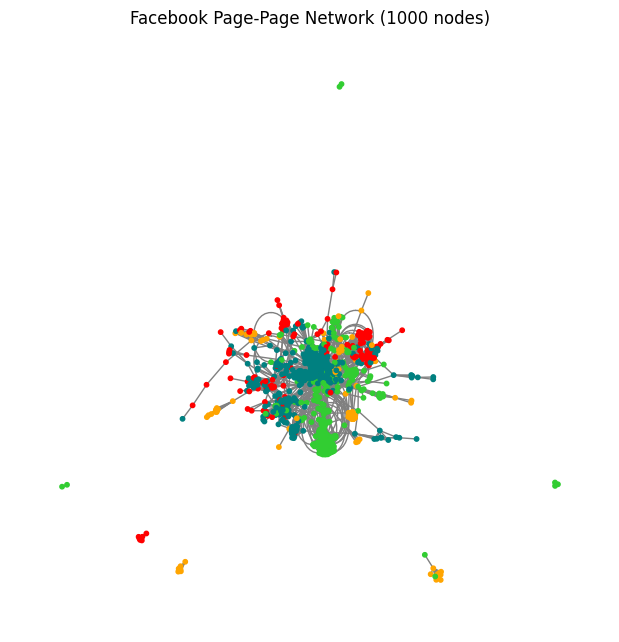

In [ ]:
# Draw the networkx graph, with nodes colored by the attribute 'page_type'
# Note: this is a subset of the full network, as I don't have enough compute power to visualize the whole network at the time of making this chapter

sampled_graph = G.subgraph(list(G.nodes)[:1000])  # Take a subset

# Plot using spring layout
pos = nx.spring_layout(sampled_graph)
plt.figure(figsize=(6, 6))

page_type_color = {
    'government': 'teal',
    'company': 'limegreen',
    'tvshow': 'orange',
    'politician': 'red',
}
node_colors = [page_type_color[sampled_graph.nodes[n]['page_type']] for n in sampled_graph.nodes]

nx.draw(sampled_graph, with_labels=False, node_color=node_colors, node_size=10, edge_color='gray')
plt.title("Facebook Page-Page Network (1000 nodes)")
plt.show()


Now we have a 'choose your own adventure' activity. You have access to the full Facebook network, as well as the option to look at a subset of the network (see 'nx.subgraph'). Using the tools and concepts we talked about today, choose from the following activities (or explore something on your own!):

  * Compare the values of the homophily measures we went over today - do they give similar results? Why or why not?
  * Detect communities, and then see if there is homophily in those communities
  * Add new edges based on node attributes, and then see if network attributes are similar to those of the original network
  * Calculate centrality measures in the network, and see if they are correlated with homophily measures
  * Etc.!

In [ ]:
# Your turn!

# Explore homophily in the Facebook network

### YOUR CODE HERE ###

## Section 5: Further study

* Other networks in which to study homophily:
  * Twitter Political Polarization Dataset (https://snap.stanford.edu/data/twitter7.html)
  * GitHub Collaboration Network (https://github.com/tmickleydoyle/github-collaboration-network)
  * Collaboration Networks (Co-Authorship Networks) (https://www.pnas.org/doi/10.1073/pnas.0307545100)
* Advanced topics and measures of homophily:
  * The Popularity-Homophily Index [6]
  * Homophily: Measures and Meaning [9]
  * A novel method for assessing and measuring homophily in networks through second-order statistics [12]

_______

## References and further resources:

[1] McPherson, Miller, Lynn Smith-Lovin, and James M. Cook. "Birds of a feather: Homophily in social networks." Annual review of sociology 27.1 (2001): 415-444.

[2] Lazarsfeld, Paul F., and Robert K. Merton. "Friendship as a social process: A substantive and methodological analysis." Freedom and control in modern society 18.1 (1954): 18-66.

[3] McPherson, J. Miller, and Lynn Smith-Lovin. "Homophily in voluntary organizations: Status distance and the composition of face-to-face groups." American sociological review (1987): 370-379.

[4] Kim, Kibae, and Jörn Altmann. "Effect of homophily on network formation." Communications in Nonlinear Science and Numerical Simulation 44 (2017): 482-494.

[5] Krackhardt, David, and Robert N. Stern. "Informal networks and organizational crises: An experimental simulation." Social psychology quarterly (1988): 123-140.

[6] Oswal, Shiva. "The Popularity-Homophily Index: A new way to measure Homophily in Directed Graphs." arXiv preprint arXiv:2109.00348 (2021).

[7] Karimi, Fariba, and Marcos Oliveira. "On the inadequacy of nominal assortativity for assessing homophily in networks." Scientific Reports 13.1 (2023): 21053.

[8] Cohen, Israel, et al. "Pearson correlation coefficient." Noise reduction in speech processing (2009): 1-4.

[9] Lawrence, Barbara S., and Neha Parikh Shah. "Homophily: Measures and meaning." Academy of Management Annals 14.2 (2020): 513-597.

[10] Jackson, Matthew O., and Dunia López-Pintado. "Diffusion and contagion in networks with heterogeneous agents and homophily." Network Science 1.1 (2013): 49-67.

[11] Bu, Yi, Joy Parkinson, and Park Thaichon. "Influencer marketing: Homophily, customer value co-creation behaviour and purchase intention." Journal of Retailing and Consumer Services 66 (2022): 102904.

[12] Apollonio, Nicola, Paolo G. Franciosa, and Daniele Santoni. "A novel method for assessing and measuring homophily in networks through second-order statistics." Scientific reports 12.1 (2022): 9757.

[13] Barnes, Michele L., et al. "Social networks and environmental outcomes." Proceedings of the National Academy of Sciences 113.23 (2016): 6466-6471.

[14] Adamic, Lada A., and Natalie Glance. "The political blogosphere and the 2004 US election: divided they blog." Proceedings of the 3rd international workshop on Link discovery. 2005.

[15] Kandel, Denise B. "Homophily, selection, and socialization in adolescent friendships 1." Interpersonal development. Routledge, 2017. 249-258.

[16] Newman, Mark EJ. "Mixing patterns in networks." Physical review E 67.2 (2003): 026126.

[17] Feld, Scott L. "Why your friends have more friends than you do." American journal of sociology 96.6 (1991): 1464-1477.

[18] Cheng, Shu, et al. "Exploring biotic interactions within protist cell populations using network methods." Journal of Eukaryotic Microbiology 61.4 (2014): 399-403.

[19] Lusseau, David, and Mark EJ Newman. "Identifying the role that animals play in their social networks." Proceedings of the Royal Society of London. Series B: Biological Sciences 271.suppl_6 (2004): S477-S481.

[20] Mark, Noah P. "Culture and competition: Homophily and distancing explanations for cultural niches." American sociological review 68.3 (2003): 319-345.

[21] Karimi, Fariba, et al. "Homophily influences ranking of minorities in social networks." Scientific reports 8.1 (2018): 11077.

[22] Barabási, A.-L., Pósfai, M. (2016). Network science. Cambridge: Cambridge University Press. ISBN: 9781107076266 1107076269
